In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ee
ee.Authenticate()
ee.Initialize()


Successfully saved authorization token.


In [2]:
full_collection = ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')

first_img = full_collection.first()
print(first_img.bandNames().getInfo())

['NO2_column_number_density', 'tropospheric_NO2_column_number_density', 'stratospheric_NO2_column_number_density', 'NO2_slant_column_number_density', 'tropopause_pressure', 'absorbing_aerosol_index', 'cloud_fraction', 'sensor_altitude', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'solar_zenith_angle']


In [3]:

test_start = ee.Date('2024-02-01')
test_end = ee.Date('2024-02-28')
collection = (
    ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
    .select('tropospheric_NO2_column_number_density')
    .filterDate(test_start, test_end)  # full month
)

In [4]:
from IPython.display import Image, display


point = ee.Geometry.Point([77.02, 28.99])
start = test_start
end = test_end
n_days = end.difference(start, 'day')

days = ee.List.sequence(0, n_days.subtract(1))



def make_daily(d):
    date = start.advance(d, 'day')
    
    img = (
        collection
        .filterDate(date, date.advance(1, 'day'))
        .mean()
        .set('date', date.format('YYYY-MM-dd'))
    )
    return img

daily_collection = ee.ImageCollection(days.map(make_daily))

# Visualize first daily image (inline in notebook)
vis_params = {
    'min': 0,
    'max': 5e-5,
    'palette': ['white', 'blue', 'purple', 'cyan', 'green', 'yellow', 'red']
}

img_to_show = ee.Image(daily_collection.first()).visualize(**vis_params)
region = point.buffer(100000).bounds()
first_daily = ee.Image(daily_collection.first()).select('tropospheric_NO2_column_number_density')

valid_count = ee.Number(first_daily.reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=1000,
    maxPixels=1e9,
    bestEffort=True
).get('tropospheric_NO2_column_number_density'))

total_count = ee.Number(ee.Image.constant(1).reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=1000,
    maxPixels=1e9,
    bestEffort=True
).get('constant'))

missing_count = total_count.subtract(valid_count)
missing_pct = missing_count.divide(total_count).multiply(100)

print(f"Valid pixels: {int(valid_count.getInfo())}")
print(f"Missing pixels: {int(missing_count.getInfo())}")
print(f"Missing data: {missing_pct.getInfo():.2f}%")
thumb_url = img_to_show.getThumbURL({
    'region': point.buffer(100000).bounds(),
    'dimensions': 512,
    'format': 'png'
})

display(Image(url=thumb_url))

Valid pixels: 0
Missing pixels: 45600
Missing data: 100.00%


In [2]:
def add_missing_stats(img):
    band = 'tropospheric_NO2_column_number_density'
    
    valid_count = ee.Number(img.select(band).reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=region,
        scale=1000,
        maxPixels=1e9,
        bestEffort=True
    ).get(band))
    
    total_count = ee.Number(ee.Image.constant(1).reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=region,
        scale=1000,
        maxPixels=1e9,
        bestEffort=True
    ).get('constant'))
    
    missing_pct = total_count.subtract(valid_count).divide(total_count).multiply(100)
    
    return img.set({
        'valid_pixels': valid_count,
        'missing_pct': missing_pct
    })

daily_with_stats = daily_collection.map(add_missing_stats)

stats_list = daily_with_stats.aggregate_array('missing_pct').getInfo()
dates_list = daily_with_stats.aggregate_array('date').getInfo()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(dates_list, stats_list)
plt.xticks(rotation=45)
plt.ylabel("Missing %")
plt.title("Daily Missing Data (Sentinel-5P NO2)")
plt.tight_layout()
plt.show()

def missing_mask(img):
    band = 'tropospheric_NO2_column_number_density'
    mask = img.select(band).mask()  # 1 where valid
    missing = mask.Not()            # 1 where missing
    return missing.rename('missing')

missing_collection = daily_collection.map(missing_mask)

missing_frequency = missing_collection.mean()


NameError: name 'daily_collection' is not defined

In [3]:
point = ee.Geometry.Point([77.02, 28.99])  # Sonipat-ish

def extract_value(img):
    value = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=point,
        scale=1000,
        maxPixels=1e9
    )
    
    # Safely handle missing values
    no2 = ee.Algorithms.If(
        value.contains('tropospheric_NO2_column_number_density'),
        value.get('tropospheric_NO2_column_number_density'),
        -999
    )
    
    return ee.Feature(None, {
        'date': img.get('date'),
        'no2': no2
    })

ts = daily_collection.map(extract_value)

NameError: name 'ee' is not defined

In [ ]:
features = ts.getInfo()['features']
print(features)
data = [
    (
        f['properties'].get('date'),
        f['properties'].get('no2')  # safe access
    )
    for f in features
]

df = pd.DataFrame(data, columns=['date', 'no2'])  # dropna to handle missing values
mask_missing = df['no2'].isna()



df['no2_interp'] = (
    df['no2']
    .interpolate()                # main interpolation
    .ffill()                      # forward fill
    .bfill()                      # backward fill
)
df = df.sort_values('date')

noise_std = df['no2_interp'].std() * 0.4

df.loc[mask_missing, 'no2_interp'] += np.random.normal(
    0, noise_std, size=mask_missing.sum()
)
print(df)

[{'type': 'Feature', 'geometry': None, 'id': '0', 'properties': {'date': '2024-02-01'}}, {'type': 'Feature', 'geometry': None, 'id': '1', 'properties': {'date': '2024-02-02', 'no2': 1.9649254682005978e-05}}, {'type': 'Feature', 'geometry': None, 'id': '2', 'properties': {'date': '2024-02-03', 'no2': 7.452393765560449e-05}}, {'type': 'Feature', 'geometry': None, 'id': '3', 'properties': {'date': '2024-02-04'}}, {'type': 'Feature', 'geometry': None, 'id': '4', 'properties': {'date': '2024-02-05'}}, {'type': 'Feature', 'geometry': None, 'id': '5', 'properties': {'date': '2024-02-06', 'no2': 3.265506165916666e-05}}, {'type': 'Feature', 'geometry': None, 'id': '6', 'properties': {'date': '2024-02-07', 'no2': 5.1480907131912015e-05}}, {'type': 'Feature', 'geometry': None, 'id': '7', 'properties': {'date': '2024-02-08', 'no2': 2.8481761546569482e-05}}, {'type': 'Feature', 'geometry': None, 'id': '8', 'properties': {'date': '2024-02-09', 'no2': 3.0215629336289023e-05}}, {'type': 'Feature', 'ge

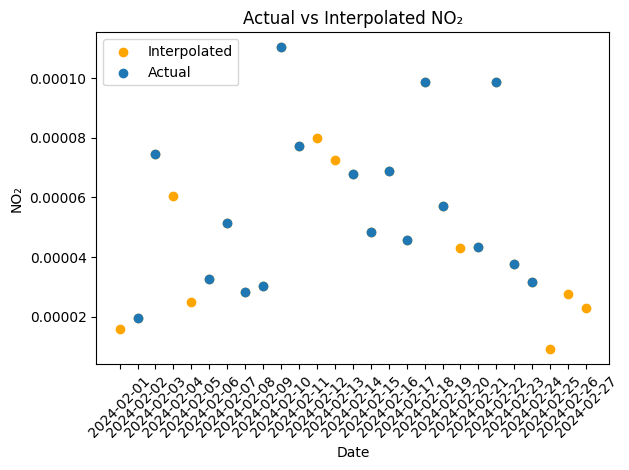

In [8]:
df = df.sort_values('date')

# Plot interpolated (continuous line)
plt.scatter(df['date'], df['no2_interp'], label='Interpolated', zorder=3, color='orange')

# Plot actual values ONLY (skip NaNs automatically)
plt.scatter(df['date'], df['no2'], label='Actual', zorder=3)

plt.xlabel('Date')
plt.ylabel('NO₂')
plt.title('Actual vs Interpolated NO₂')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()